Importing Libraries and Setting Up the Environment

In [1]:
import numpy as np
import pandas as pd 

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


Collecting Historical Gold Price Data

In [2]:
stocks = input("Enter the code of the stock:- ")
# Download historical Gold Futures data
data = yf.download(
    stocks,
    "2010-01-01",
    "2026-01-01",
    auto_adjust=True
)

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.400959,6.415615,6.352207,6.383612,493729600
2010-01-05,6.412027,6.448218,6.378229,6.418607,601904800
2010-01-06,6.310034,6.437449,6.303454,6.412026,552160000
2010-01-07,6.298370,6.340842,6.252608,6.333365,477131200
2010-01-08,6.340243,6.340842,6.252908,6.289995,447610800


In [3]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4024 entries, 2010-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   4024 non-null   float64
 1   (High, AAPL)    4024 non-null   float64
 2   (Low, AAPL)     4024 non-null   float64
 3   (Open, AAPL)    4024 non-null   float64
 4   (Volume, AAPL)  4024 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 188.6 KB


In [4]:
data.shape

(4024, 5)

In [5]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,4024.000000,4024.000000,4024.000000,4024.000000,4.024000e+03
mean,77.300371,78.064661,76.463419,77.235968,2.190006e+08
std,74.826808,75.550358,74.023624,74.746466,2.154860e+08
min,5.744146,5.862287,5.690307,5.753717,1.791060e+07
25%,18.178101,18.371392,18.027059,18.197695,7.765910e+07
50%,38.776930,39.218552,38.254173,38.735390,1.307822e+08
75%,142.543816,144.076111,140.859050,142.398292,2.899995e+08
max,285.413116,287.836529,282.530963,285.423116,1.880998e+09


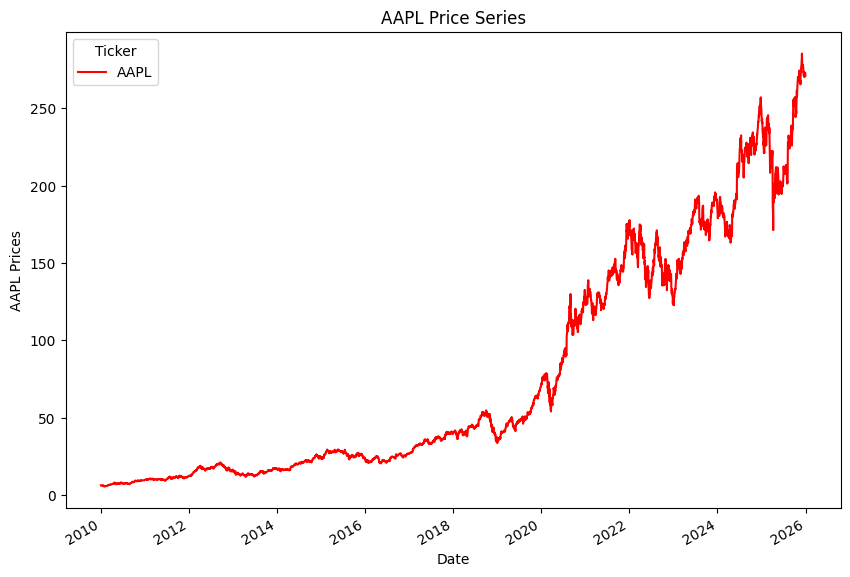

In [6]:
data.Close.plot(figsize=(10, 7), color='r')
plt.ylabel("{} Prices".format(stocks))
plt.title("{} Price Series".format(stocks))
plt.show()


<Axes: ylabel='Count'>

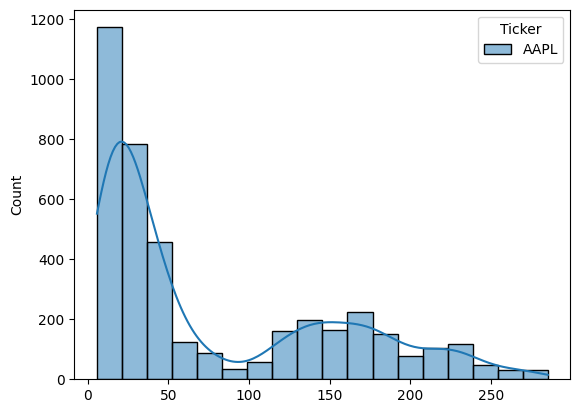

In [7]:
sns.histplot(data["Close"], kde=True)


<Axes: ylabel='Count'>

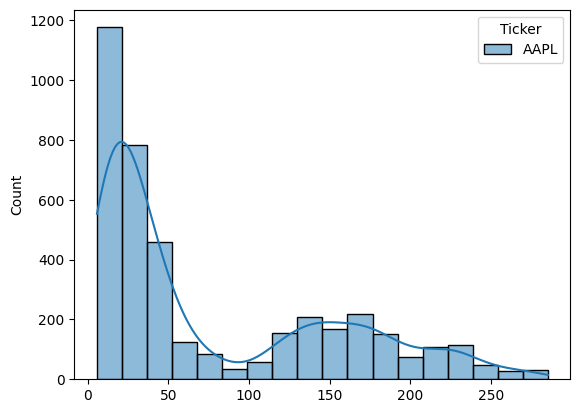

In [8]:
sns.histplot(data["Open"], kde=True)


<Axes: ylabel='Count'>

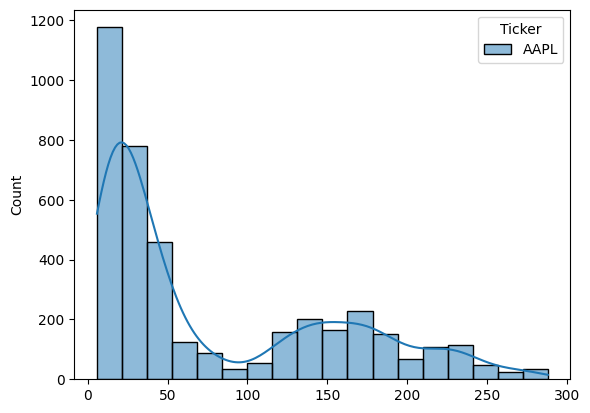

In [9]:
sns.histplot(data["High"], kde=True)

In [10]:
x = data.drop("Close" , axis = 1)
y = data["Close"]

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3219, 4)
(805, 4)
(3219, 1)
(805, 1)


In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
pred1 = lr.predict(x_test)


In [13]:
pred1

array([[  92.88058883],
       [  88.9859974 ],
       [  67.1316196 ],
       [ 103.96142914],
       [ -73.00426801],
       [  76.05335007],
       [ 101.79503427],
       [  96.91586745],
       [  80.97058703],
       [ 108.98149858],
       [ 100.96837947],
       [ 108.94344802],
       [ 102.86021497],
       [ 103.60236737],
       [ 113.19633747],
       [  17.92564484],
       [  69.60022562],
       [  99.90672378],
       [  30.62838296],
       [  95.32357975],
       [  85.24689824],
       [  82.05527281],
       [  98.11131698],
       [ 113.28644072],
       [ 107.89879073],
       [  80.47920017],
       [  96.75113182],
       [  95.96066716],
       [  52.08419926],
       [ 108.26562712],
       [ 108.63545977],
       [ 104.35264687],
       [ 108.01300116],
       [  76.17147718],
       [  30.33063684],
       [  36.05909687],
       [ 107.00061732],
       [ 103.93479571],
       [ 109.88464617],
       [  80.66806255],
       [  65.55131695],
       [ 100.016

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

def calculate_metrics(y_test, y_pred):
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_scors = r2_score(y_test, y_pred)

    print("MSE:- ", mse)
    print("RMSE:- ", rmse)
    print("R2_score:- ", r2_scors)

calculate_metrics(y_test, pred1)


MSE:-  4049.420001672707
RMSE:-  63.63505324640427
R2_score:-  0.30123104865313166


In [15]:
from sklearn.linear_model import Lasso , Ridge

la = Lasso().fit(x_train , y_train)
ri = Ridge().fit(x_train , y_train)

la_p = la.predict(x_test)
ri_p = ri.predict(x_test)


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.1408105882907606e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [16]:
calculate_metrics(y_test , la_p)

MSE:-  0.7835799092202784
RMSE:-  0.8852004909738124
R2_score:-  0.999864785250422


In [17]:
calculate_metrics(y_test ,ri_p)

MSE:-  0.43887977565803843
RMSE:-  0.6624800190632457
R2_score:-  0.9999242667936452


In [18]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr = SVR()
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(svr, param_grid, refit=True, verbose=3)
grid.fit(x_train , y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.303 total time=   0.2s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.202 total time=   0.2s


...

[CV 4/5] END ..C=1000, gamma=0.0001, kernel=rbf;, score=0.000 total time=   0.3s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 5/5] END .C=1000, gamma=0.0001, kernel=rbf;, score=-0.000 total time=   0.3s


c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is u

In [19]:
svr = SVR(C=1000, gamma=0.0001, kernel='rbf') 

svr.fit(x_train, y_train)

svr_pred = svr.predict(x_test)

c:\Users\JATIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [20]:
calculate_metrics(y_test, svr_pred)

MSE:-  5766.344407861041
RMSE:-  75.9364497975843
R2_score:-  0.004958133924975794


In [21]:
import joblib

joblib.dump(ri, "apple_model.pkl")

ridge_from_joblib = model = joblib.load("apple_model.pkl")

In [22]:
model = joblib.load("apple_model.pkl")

In [23]:
prediction = model.predict(x_test)

print(prediction[:5])

[26.51106868 68.51635544 13.04402454 35.59031854  7.5705697 ]


In [24]:
print("Predicted:", prediction[:5])
print("Actual:   ", y_test[:5].values)

Predicted: [26.51106868 68.51635544 13.04402454 35.59031854  7.5705697 ]
Actual:    [[26.58483124]
 [69.14833832]
 [12.98307514]
 [35.71779633]
 [ 7.59674597]]
